# 1. Explore

Module importing

In [43]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Library importing

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from src.config import EOL_AH, V_GRID, FIGURES_DIR
from src.data import load_cache, clean_capacity, cycle_life

Sanity check

In [45]:
cells = load_cache()
lives = {cid: cycle_life(c["qd"]) for cid, c in cells.items()}
print(len(cells), "cells;", sum(np.isnan(v) for v in lives.values()), "never reached 80%")

c = cells["b1c0"]
print(c["qd"][:10])          # capacity of the first 10 cycles
print(c["qdlin"].shape)      # expect (100, 1000)
print(c["charge_time"][:5])  # unit check

180 cells; 7 never reached 80%
[1.0706892 1.0719005 1.0725095 1.073174  1.0735761 1.0739917 1.0743741
 1.0744922 1.0745373 1.0747814]
(100, 1000)
[32.59116333 31.84131833 32.00736833 31.92464667 32.00746333]


Plotting every cell's capacity fade

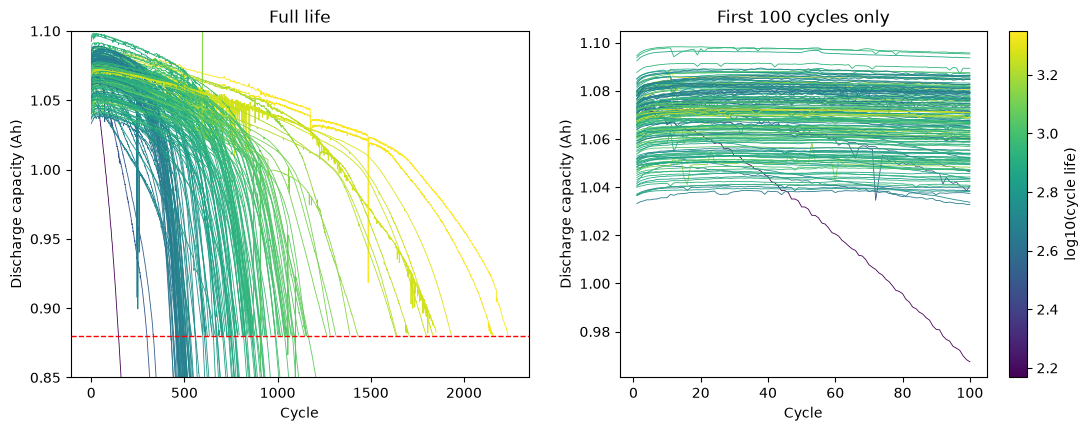

In [46]:
valid = {k: v for k, v in lives.items() if not np.isnan(v)}
norm = plt.Normalize(np.log10(min(valid.values())), np.log10(max(valid.values())))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
for cid, life in valid.items():
    qd = clean_capacity(cells[cid]["qd"])
    color = plt.cm.viridis(norm(np.log10(life)))
    a1.plot(np.arange(1, len(qd) + 1), qd, color=color, lw=0.6)
    a2.plot(np.arange(1, 101), qd[:100], color=color, lw=0.6)
a1.axhline(EOL_AH, ls="--", c="red", lw=1)
a1.set(xlabel="Cycle", ylabel="Discharge capacity (Ah)", ylim=(0.85, 1.1), title="Full life")
a2.set(xlabel="Cycle", ylabel="Discharge capacity (Ah)", title="First 100 cycles only")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=a2, label="log10(cycle life)")
fig.savefig(FIGURES_DIR / "capacity_fade.png", dpi=150, bbox_inches="tight")

Q(V) and ΔQ(V)

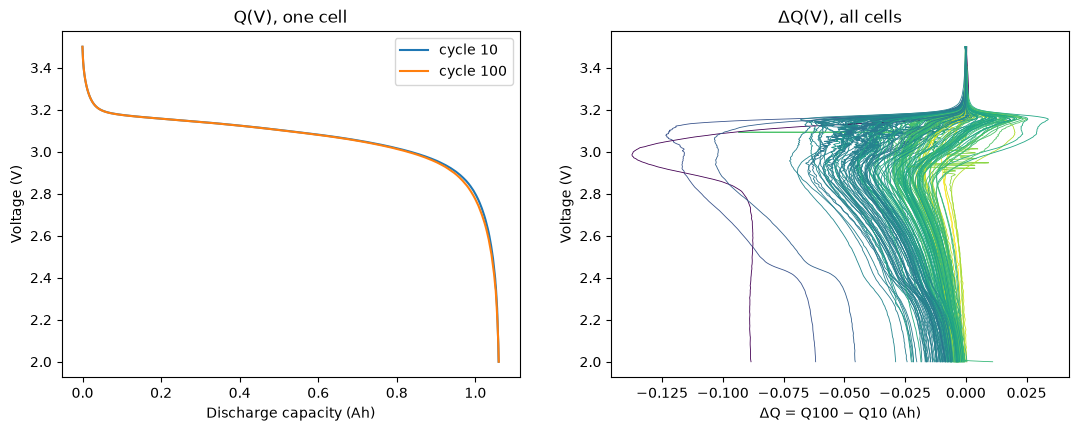

In [47]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
c = cells["b1c0"]
a1.plot(c["qdlin"][9], V_GRID, label="cycle 10")
a1.plot(c["qdlin"][99], V_GRID, label="cycle 100")
a1.set(xlabel="Discharge capacity (Ah)", ylabel="Voltage (V)", title="Q(V), one cell")
a1.legend()

for cid, life in valid.items():
    dq = cells[cid]["qdlin"][99] - cells[cid]["qdlin"][9]
    a2.plot(dq, V_GRID, color=plt.cm.viridis(norm(np.log10(life))), lw=0.6)
a2.set(xlabel="ΔQ = Q100 − Q10 (Ah)", ylabel="Voltage (V)", title="ΔQ(V), all cells")
fig.savefig(FIGURES_DIR / "delta_q.png", dpi=150, bbox_inches="tight")

Corelation proof

In [48]:
from scipy.stats import pearsonr

ids = list(valid)
y = np.log10([valid[i] for i in ids])
cap100 = [clean_capacity(cells[i]["qd"])[99] for i in ids]
logvar = [np.log10(np.nanvar(cells[i]["qdlin"][99] - cells[i]["qdlin"][9])) for i in ids]

print("capacity at cycle 100 vs log life: r = %.2f" % pearsonr(cap100, y)[0])
print("ΔQ(V)                 vs log life: r = %.2f" % pearsonr(logvar, y)[0])

capacity at cycle 100 vs log life: r = 0.18
ΔQ(V)                 vs log life: r = -0.87


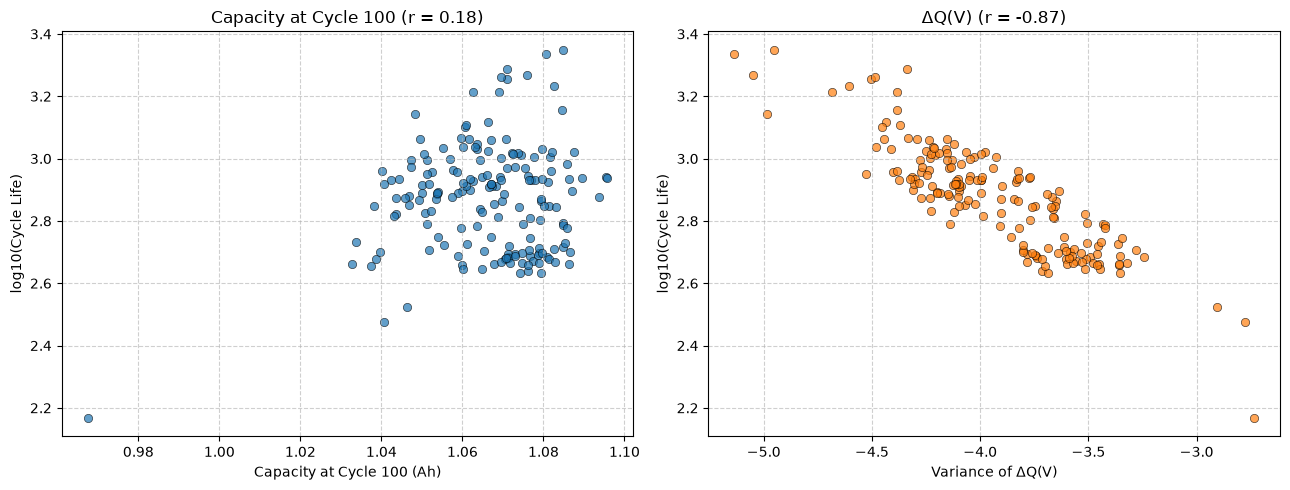

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

r_cap = pearsonr(cap100, y)[0]
ax1.scatter(cap100, y, alpha=0.7, color="tab:blue", edgecolors="k", linewidths=0.5)
ax1.set(
    xlabel="Capacity at Cycle 100 (Ah)",
    ylabel="log10(Cycle Life)",
    title=f"Capacity at Cycle 100 (r = {r_cap:.2f})"
)
ax1.grid(True, linestyle="--", alpha=0.6)

r_var = pearsonr(logvar, y)[0]
ax2.scatter(logvar, y, alpha=0.7, color="tab:orange", edgecolors="k", linewidths=0.5)
ax2.set(
    xlabel="Variance of ΔQ(V)",
    ylabel="log10(Cycle Life)",
    title=f"ΔQ(V) (r = {r_var:.2f})"
)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "persuasive_comparison.png", dpi=150, bbox_inches="tight")
plt.show()